In [1]:
!pip install opencv-python

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
import cv2 as cv
import numpy as np

train_dir = 'animals-detection-images-dataset/train/'
test_dir = 'animals-detection-images-dataset/test/'

# List of labels from directory names
labels = os.listdir(train_dir)

labels = ['Butterfly',
          'Caterpillar', 'Chicken', 'Crab',
          'Deer', 'Duck', 'Eagle', 'Fish',
          'Frog', 'Giraffe', 'Goose', 'Horse',
          'Jellyfish', 'Ladybug', 'Lion',
          'Lizard', 'Monkey', 'Owl', 'Parrot',
          'Penguin',
          'Shark', 'Snail', 'Snake',
          'Sparrow', 'Spider', 'Squirrel',
          'Tiger', 'Tortoise', 'Whale']

label_len = len(labels)
print(label_len)

# Lists to store training data
X = []
Y = []

# Load the data
for label in labels:
    folder_path = os.path.join(train_dir, label)
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv.imread(img_path)
        if img is not None:
            # Resize image to 224x224
            img = cv.resize(img, (224, 224))
            X.append(img)
            Y.append(labels.index(label))

# Convert lists to NumPy arrays
X = np.array(X)
Y = np.array(Y)

print("Training data dimensions:")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

'''
29
Training data dimensions:
X shape: (15219, 224, 224, 3)
Y shape: (15219,)
'''


29
Training data dimensions:
X shape: (15219, 224, 224, 3)
Y shape: (15219,)



Validation data dimensions:
X_valid shape: (3922, 224, 224, 3)
Y_valid shape: (3922,)
Total number of images: 19141


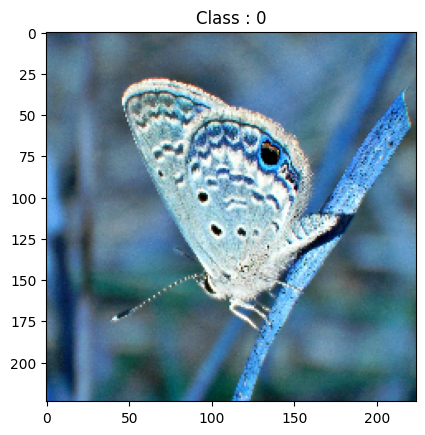

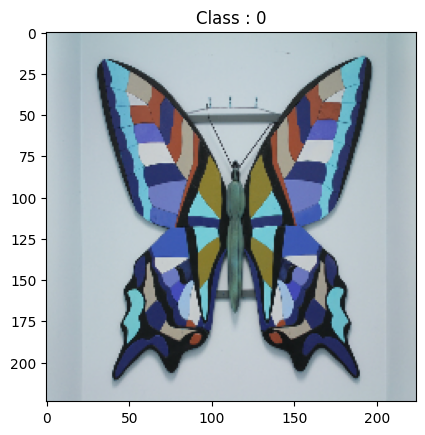

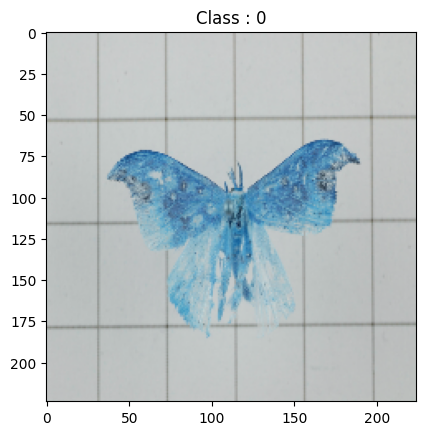

In [4]:
# Variables for validation data
X_valid = []
Y_valid = []
X_valid_path = []

# Load validation data
for label in labels:
    folder_path = os.path.join(test_dir, label)
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv.imread(img_path)
        if img is not None:
            # Resize image to 224x224
            img = cv.resize(img, (224, 224))
            X_valid.append(img)
            X_valid_path.append(img_path)
            Y_valid.append(labels.index(label))

X_valid = np.array(X_valid)
Y_valid = np.array(Y_valid)

print("\nValidation data dimensions:")
print("X_valid shape:", X_valid.shape)
print("Y_valid shape:", Y_valid.shape)

total_images = X.shape[0] + X_valid.shape[0]
print("Total number of images:", total_images)

# Display the first 3 training images with their class labels
for i in range(3):
    plt.imshow(X[i])
    plt.title(f"Class : {Y[i]}")
    plt.show()


In [7]:
import torch
import torch.nn as nn
import torchvision.models as models

# Load pre-trained ResNet50
base_model = models.resnet50(pretrained=True)

# Remove the final fully connected layer to mimic include_top=False
# This creates a feature extractor that outputs a (batch, 2048, 1, 1) feature map (if using global avg pooling)
base_model = nn.Sequential(*list(base_model.children())[:-1])

# Freeze all layers
for param in base_model.parameters():
    param.requires_grad = False


/usr/local/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/avishagnevo/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:13<00:00, 7.87MB/s]


In [8]:
import torch
import torch.nn as nn
import torchvision.models as models

class AnimalClassifier(nn.Module):
    def __init__(self, num_classes):
        super(AnimalClassifier, self).__init__()
        # Load a pre-trained ResNet50 model
        resnet = models.resnet50(pretrained=True)
        # Remove the final fully-connected layer (i.e. include_top=False)
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        
        # Freeze the ResNet50 feature extractor parameters
        for param in self.features.parameters():
            param.requires_grad = False
        
        # Define the classification head
        self.flatten = nn.Flatten()  # Alternatively, use x.view(x.size(0), -1) in forward
        self.fc1 = nn.Linear(2048, 1024)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(1024, 512)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(512, num_classes)
        self.softmax = nn.Softmax(dim=1)  # For producing probabilities
        
    def forward(self, x):
        x = self.features(x)        # Output shape: (batch, 2048, 1, 1)
        x = x.view(x.size(0), -1)     # Flatten to (batch, 2048)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# Assuming 'labels' is defined as in your previous block
num_classes = len(labels)
model = AnimalClassifier(num_classes=num_classes)

In [9]:
import torch.nn as nn
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# During training, compute accuracy like this:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return torch.sum(preds == labels.data).double() / len(labels)


In [10]:
import torch

# Convert the NumPy arrays to PyTorch tensors
Y_tensor = torch.tensor(Y)  
Y_valid_tensor = torch.tensor(Y_valid)

# Optionally, convert to one-hot vectors if needed (not required for CrossEntropyLoss)
Y_one_hot = torch.nn.functional.one_hot(Y_tensor, num_classes=label_len)
Y_valid_one_hot = torch.nn.functional.one_hot(Y_valid_tensor, num_classes=label_len)

print("Y_one_hot shape:", Y_one_hot.shape)
print("Y_valid_one_hot shape:", Y_valid_one_hot.shape)

'''
Y_one_hot shape: torch.Size([15219, 29])
Y_valid_one_hot shape: torch.Size([3922, 29])
'''


Y_one_hot shape: torch.Size([15219, 29])
Y_valid_one_hot shape: torch.Size([3922, 29])


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Convert the training and validation data to PyTorch tensors.
# Also, convert images from HWC to CHW format and normalize them (scaling pixel values between 0 and 1)
X_train_tensor = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
Y_train_tensor = torch.tensor(Y, dtype=torch.long)

X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
Y_valid_tensor = torch.tensor(Y_valid, dtype=torch.long)

# Create TensorDatasets and DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, Y_valid_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Set up the optimizer and loss criterion
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()  # Expects raw logits and integer labels

num_epochs = 1 #20

for epoch in range(num_epochs):
    # Set model to training mode
    model.train()
    running_loss = 0.0
    running_corrects = 0
    
    # Training loop
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)         # Forward pass
        loss = criterion(outputs, labels)
        loss.backward()                 # Backpropagation
        optimizer.step()                # Update weights
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)
    
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    
    # Validation loop
    model.eval()
    val_loss = 0.0
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in valid_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
    val_loss = val_loss / len(valid_dataset)
    val_acc = val_corrects.double() / len(valid_dataset)
    
    print(f"Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")


Epoch 1/1 - loss: 0.9491 - accuracy: 0.7253 - val_loss: 0.3932 - val_accuracy: 0.8723


In [14]:
import torch

# --- Saving Checkpoint ---
# Assume these variables are defined during training:
# epoch, model, optimizer, loss, etc.
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch_loss': epoch_loss,
    'val_loss': val_loss,
    'epoch_acc': epoch_acc,
    'val_acc': val_acc,
    # ... any additional keys you wish to save
}

PATH = f"checkpoints/checkpoint_{epoch}epoch.pth"
#torch.save(checkpoint, PATH)
print(f"Checkpoint saved to {PATH}")

# --- Loading Checkpoint ---
# Determine the device to load the model to (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Loading checkpoint on device:", device)

# If you want to load only the weights, use map_location
checkpoint = torch.load(PATH, map_location=device)

labels = os.listdir(train_dir)
num_classes = len(labels)

# Create your model and optimizer (using your model class and optimizer class)
model = AnimalClassifier(num_classes=num_classes)          
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Load the state dictionaries
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
epoch_loss = checkpoint['epoch_loss']
val_loss = checkpoint['val_loss']
epoch_acc = checkpoint['epoch_acc']
val_acc = checkpoint['val_acc']

# Move model to the device and set mode
model.to(device)
model.eval()  # or model.train() if continuing training

print(f"Checkpoint loaded: epoch={epoch}, loss={epoch_loss:.4f}")


Checkpoint saved to checkpoints/checkpoint_0epoch.pth
Loading checkpoint on device: cpu
Checkpoint loaded: epoch=0, loss=0.9491


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# --- Model Evaluation on Validation Data ---
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in valid_loader:
        outputs = model(inputs)  # outputs are logits
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

# Concatenate all batches
Y_pred_classes = np.concatenate(all_preds)
Y_true = np.concatenate(all_labels)

# Compute confusion matrix and accuracy
conf_matrix = confusion_matrix(Y_true, Y_pred_classes)
acc_score = accuracy_score(Y_true, Y_pred_classes)
print("Score de précision:", acc_score)

# Plot confusion matrix
plt.figure(figsize=(20,20))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title('Matrice de confusion')
plt.xlabel('Prédictions')
plt.ylabel('Vérité terrain')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# --- Plotting Training History ---
# Here, we assume you collected training history in the following lists:
# train_losses, valid_losses, train_accs, valid_accs
# For example, you could have appended epoch_loss and epoch_acc for each epoch in your training loop.

# Plot Loss History
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.title('Training and Validation Loss History')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Plot Accuracy History
plt.figure(figsize=(10, 6))
plt.plot(train_accs, label='Training Accuracy')
plt.plot(valid_accs, label='Validation Accuracy')
plt.title('Training and Validation Accuracy History')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# --- Classification Report ---
report = classification_report(Y_true, Y_pred_classes, target_names=labels)
print(report)


In [ ]:
torch.save(model.state_dict(), 'ResNet50_DEL.pth')


In [ ]:
model.load_state_dict(torch.load('ResNet50_DEL.pth'))
model.eval()
